# Credit Card Customer Risk & Spending Analysis Using Machine Learning

## Problem Statement

Credit card companies face significant challenges in managing customer risk and optimizing credit limits. Traditional methods of assessing customer creditworthiness may not always provide accurate predictions and can lead to financial losses due to defaults.

This project aims to develop a complete credit card analytics system using machine learning techniques to analyze customer behavior, identify risky customers, and support better financial decision-making.

## Project Objectives

1. Predict Customer Credit Limits using customer demographics and financial history.
2. Classify Default Risk by identifying customers likely to default on their payments.
3. Segment High-Risk Customers for targeted interventions and personalized action plans.
4. Compare multiple machine learning models and evaluate their performance.

## Machine Learning Models Used

### Regression Model
- Linear Regression

### Classification Models
- Logistic Regression
- Support Vector Machine (SVM)

## Expected Outcome

The developed models will help financial institutions:

- Improve risk management
- Reduce default losses
- Optimize credit decisions
- Better understand customer spending behavior

In [1]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Handle Class Imbalance
from imblearn.over_sampling import SMOTE

# Save Models
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset

df = pd.read_csv("default of credit card clients.csv",header=0)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(30000, 25)


In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
# Dataset Overview

print("Dataset Information")
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2  

In [6]:
# Statistical Summary

df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Data Cleaning

In [7]:
# Remove ID Column

if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)

print("ID Column Removed Successfully")

ID Column Removed Successfully


In [8]:
# Rename PAY_0 to PAY_1

df.rename(
    columns={
        'PAY_0': 'PAY_1'
    },
    inplace=True
)

print("PAY_0 Renamed Successfully")

PAY_0 Renamed Successfully


In [9]:
# Rename Target Column

df.rename(
    columns={
        'default.payment.next.month':
        'default_payment_next_month'
    },
    inplace=True
)

print("Target Column Renamed Successfully")

Target Column Renamed Successfully


In [10]:
# Verify Updated Columns

print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment_next_month']


In [11]:
# Check Missing Values

print("Missing Values in Each Column:")
print()

print(df.isnull().sum())

Missing Values in Each Column:

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_1                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default_payment_next_month    0
dtype: int64


In [12]:
# Check Duplicate Records

duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 35


In [13]:
# Remove Duplicate Rows

df.drop_duplicates(inplace=True)

print("Updated Dataset Shape:")
print(df.shape)

Updated Dataset Shape:
(29965, 24)


In [14]:
# Target Variable Distribution

print(df['default_payment_next_month'].value_counts())

default_payment_next_month
0    23335
1     6630
Name: count, dtype: int64


In [15]:
# Target Percentage Distribution

print(round(df['default_payment_next_month'].value_counts(normalize=True) * 100,2))

default_payment_next_month
0    77.87
1    22.13
Name: proportion, dtype: float64


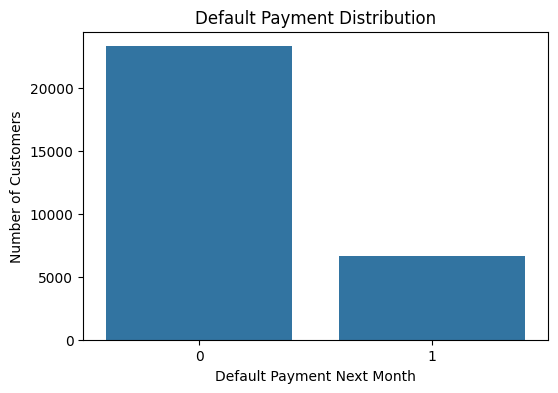

In [16]:
# Visualize Target Variable

plt.figure(figsize=(6,4))

sns.countplot(
    x='default_payment_next_month',
    data=df
)

plt.title("Default Payment Distribution")

plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")

plt.show()

Exploratory Data Analysis (EDA)

In [17]:
# Correlation Matrix

correlation_matrix = df.corr()
correlation_matrix.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
LIMIT_BAL,1.000000,0.025015,-0.218902,-0.108081,0.144643,-0.271576,-0.296302,-0.286000,-0.267300,-0.249216,...,0.294428,0.295999,0.290816,0.195454,0.178584,0.210375,0.203451,0.217421,0.219807,-0.153871
SEX,0.025015,1.000000,0.014243,-0.031372,-0.091057,-0.057932,-0.070700,-0.065954,-0.060013,-0.054886,...,-0.021902,-0.017023,-0.016750,-0.000240,-0.001390,-0.008599,-0.002227,-0.001665,-0.002765,-0.039742
EDUCATION,-0.218902,0.014243,1.000000,-0.143531,0.175080,0.105925,0.120765,0.113229,0.107992,0.096693,...,-0.000874,-0.007989,-0.009516,-0.037693,-0.030216,-0.040152,-0.038433,-0.040579,-0.037405,0.028017
MARRIAGE,-0.108081,-0.031372,-0.143531,1.000000,-0.413901,0.019977,0.024181,0.032641,0.033074,0.035585,...,-0.023376,-0.025426,-0.021236,-0.005985,-0.008099,-0.003545,-0.012668,-0.001207,-0.006646,-0.024019
AGE,0.144643,-0.091057,0.175080,-0.413901,1.000000,-0.039656,-0.050477,-0.053312,-0.049970,-0.054078,...,0.051209,0.049202,0.047470,0.026068,0.021726,0.029181,0.021306,0.022777,0.019409,0.013619


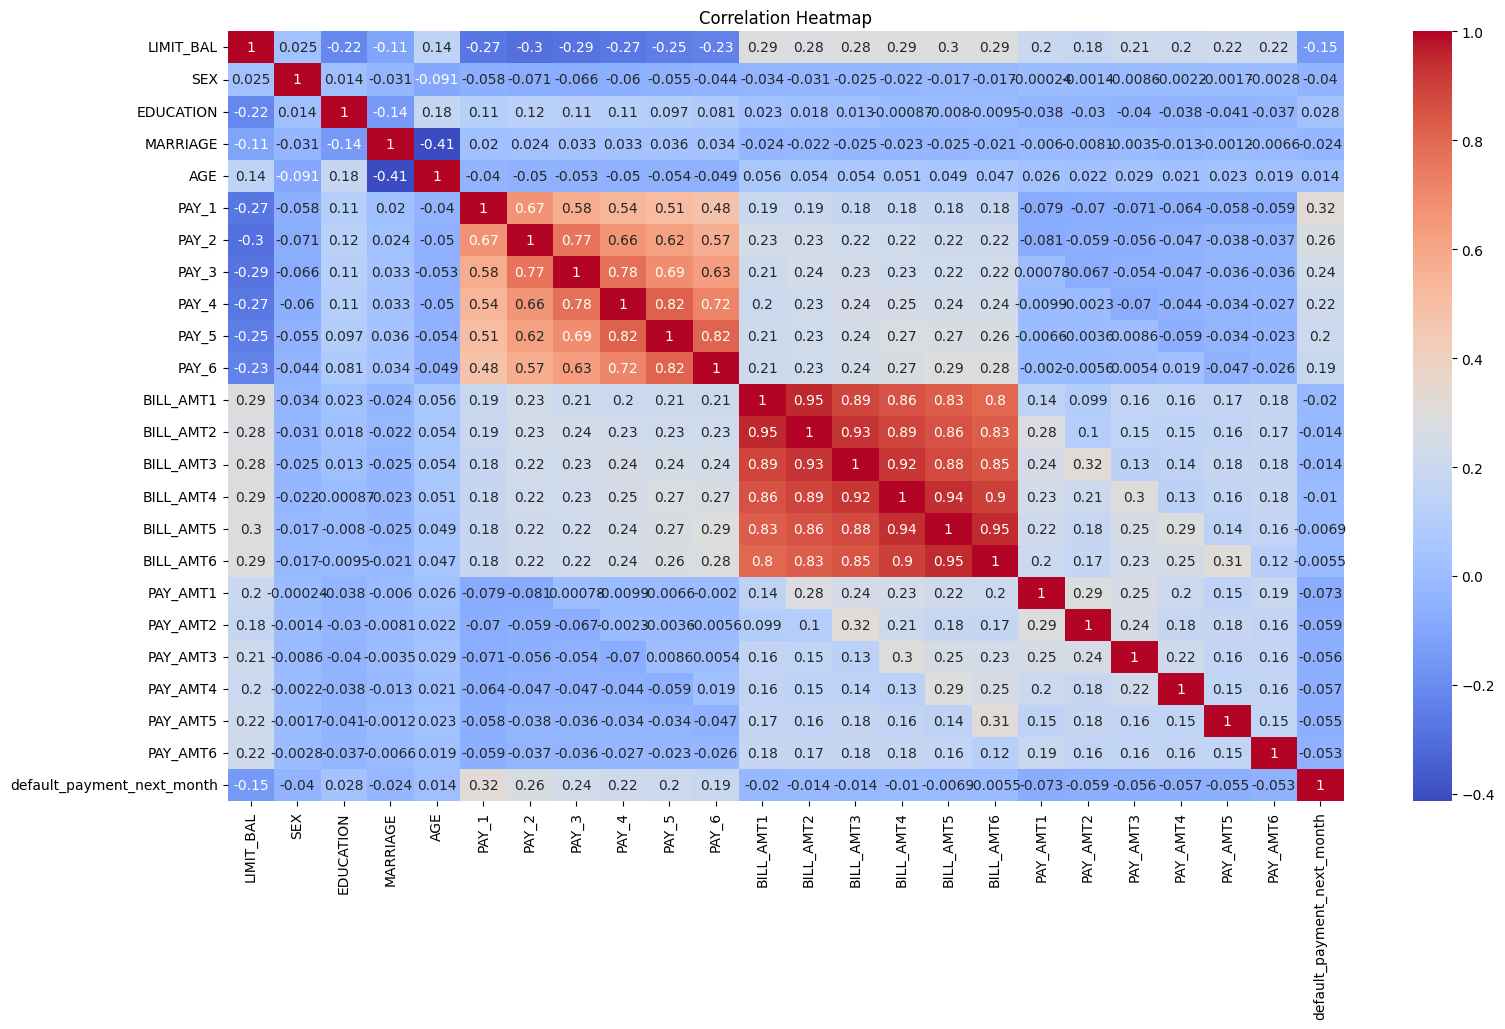

In [18]:
# Correlation Heatmap

plt.figure(figsize=(18,10))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
# Correlation With Target Variable

target_corr = (
    df.corr()['default_payment_next_month']
    .sort_values(ascending=False)
)

print(target_corr)

default_payment_next_month    1.000000
PAY_1                         0.324964
PAY_2                         0.263656
PAY_3                         0.235230
PAY_4                         0.216551
PAY_5                         0.204059
PAY_6                         0.186740
EDUCATION                     0.028017
AGE                           0.013619
BILL_AMT6                    -0.005469
BILL_AMT5                    -0.006859
BILL_AMT4                    -0.010259
BILL_AMT3                    -0.014182
BILL_AMT2                    -0.014302
BILL_AMT1                    -0.019758
MARRIAGE                     -0.024019
SEX                          -0.039742
PAY_AMT6                     -0.053250
PAY_AMT5                     -0.055194
PAY_AMT3                     -0.056319
PAY_AMT4                     -0.056898
PAY_AMT2                     -0.058643
PAY_AMT1                     -0.073015
LIMIT_BAL                    -0.153871
Name: default_payment_next_month, dtype: float64


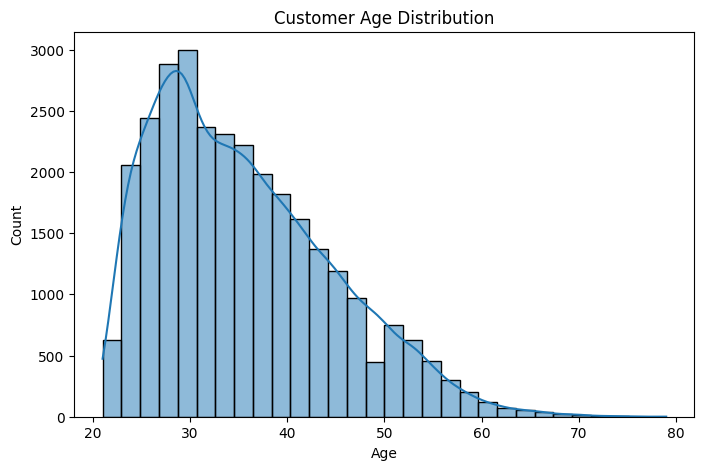

In [20]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['AGE'],
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")

plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

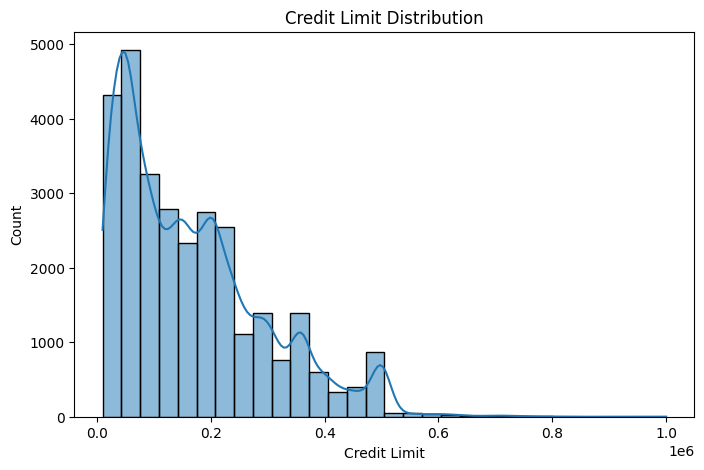

In [21]:
# Credit Limit Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['LIMIT_BAL'],
    bins=30,
    kde=True
)

plt.title("Credit Limit Distribution")

plt.xlabel("Credit Limit")
plt.ylabel("Count")

plt.show()

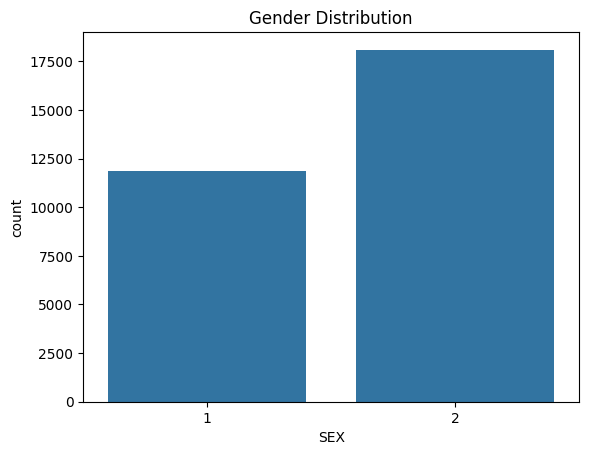

In [22]:
# Gender Distribution

sns.countplot(
    x='SEX',
    data=df
)

plt.title("Gender Distribution")

plt.show()

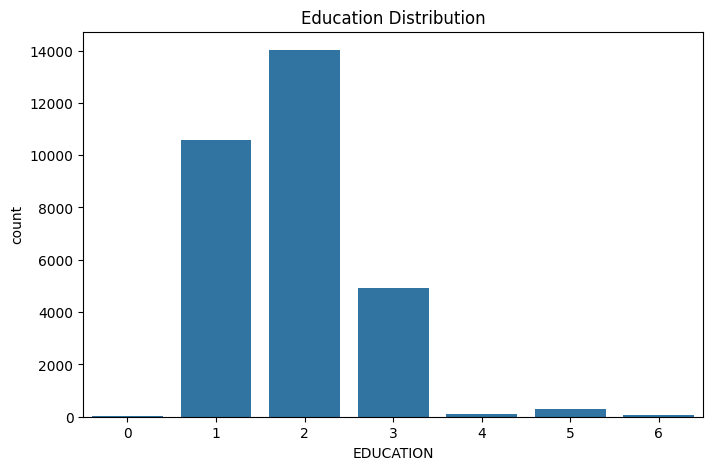

In [23]:
# Education Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='EDUCATION',
    data=df
)

plt.title("Education Distribution")

plt.show()

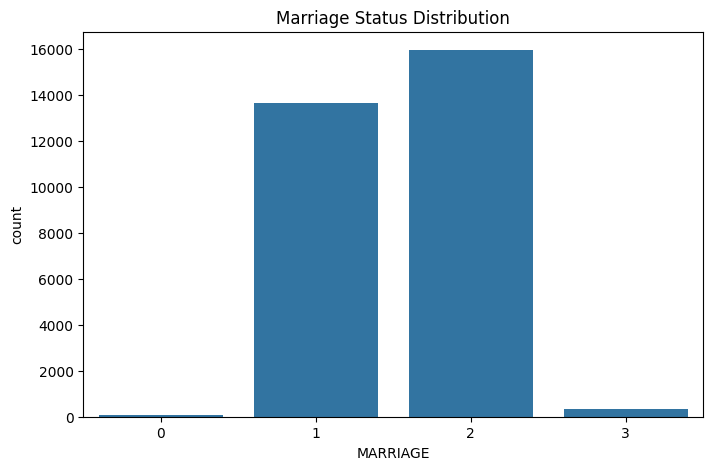

In [24]:
# Marriage Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='MARRIAGE',
    data=df
)

plt.title("Marriage Status Distribution")

plt.show()

In [25]:
# Numerical Columns

numeric_cols = df.select_dtypes(include=np.number).columns

print("Total Numerical Columns:", len(numeric_cols))

print(numeric_cols)

Total Numerical Columns: 24
Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default_payment_next_month'],
      dtype='object')


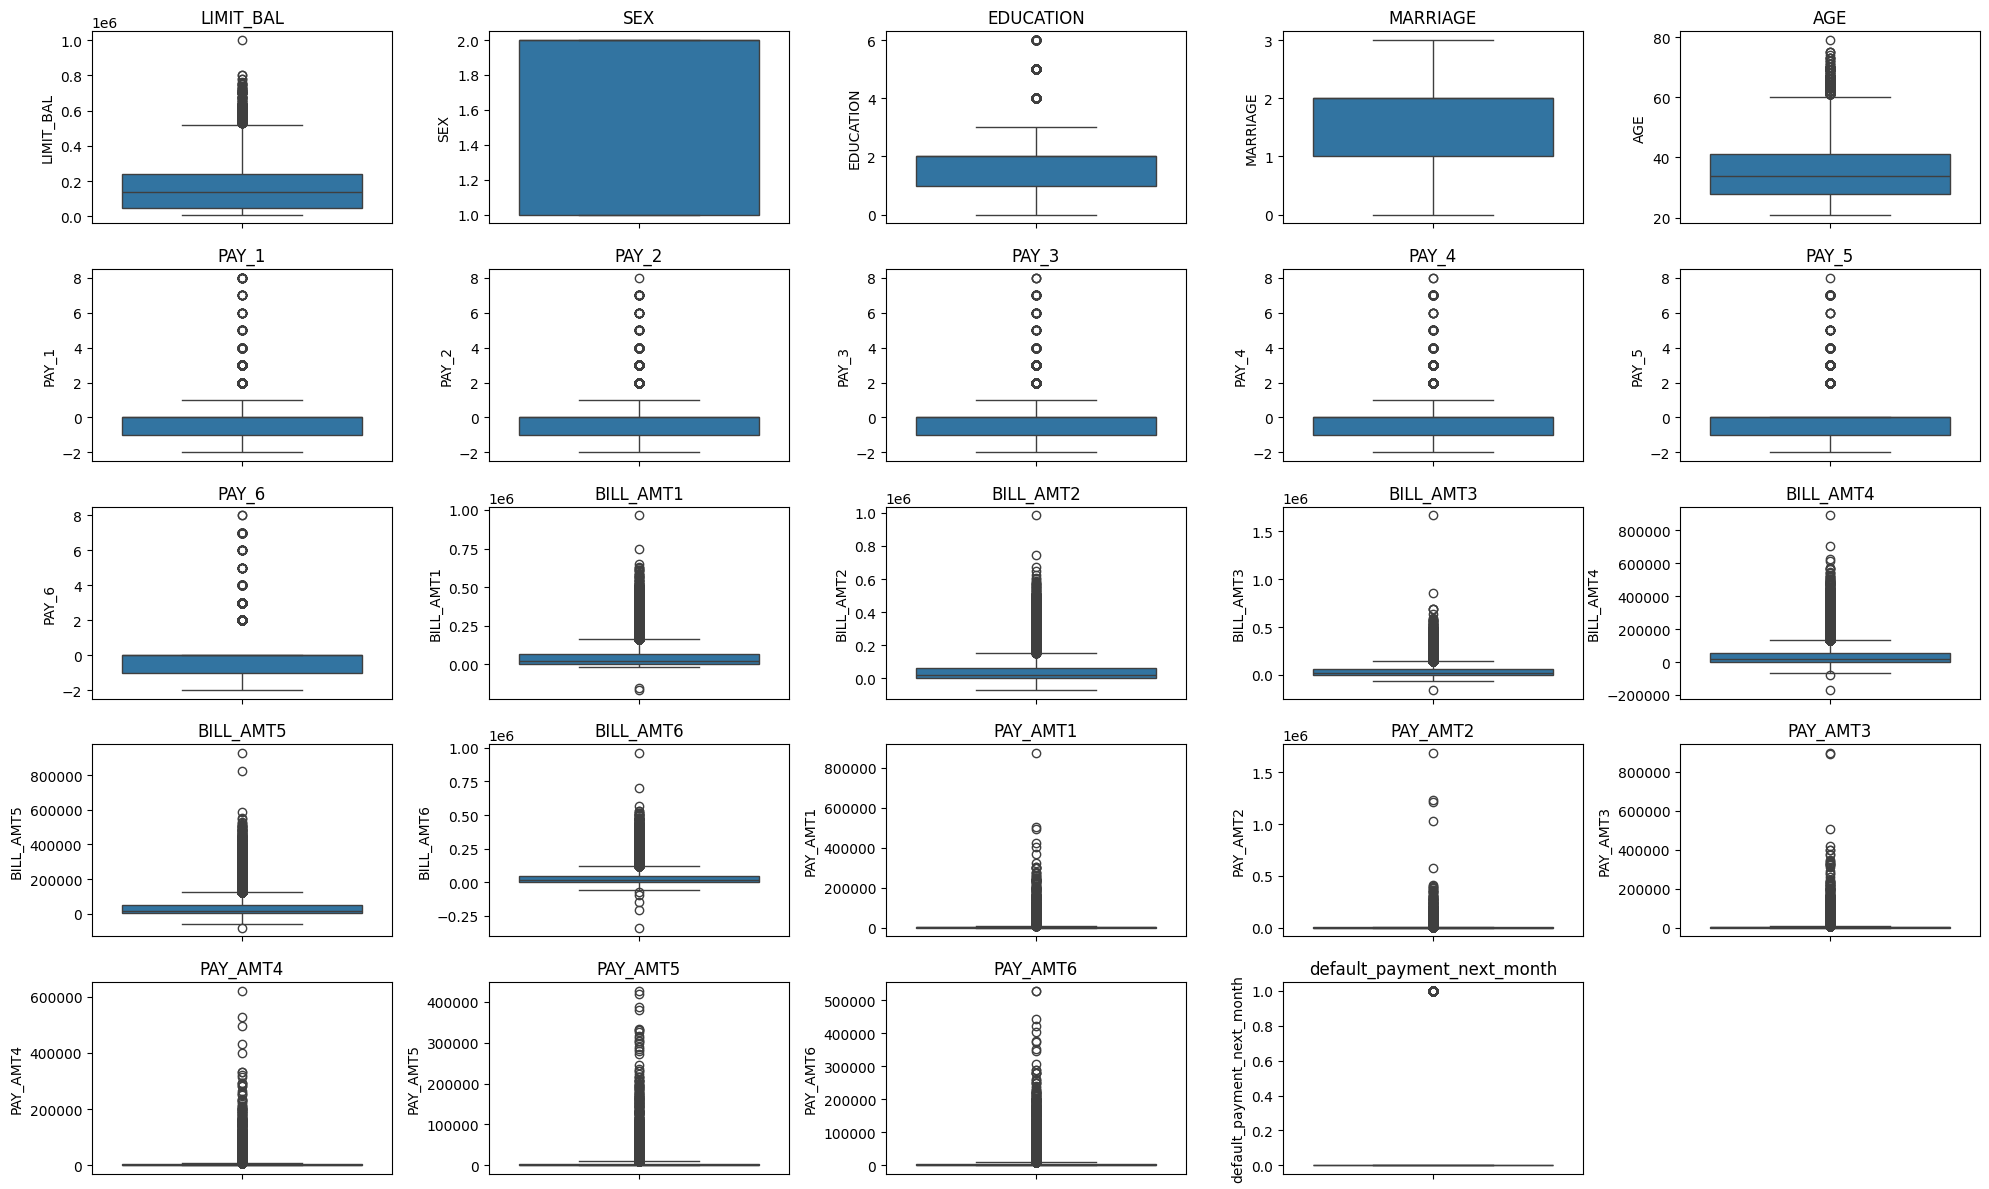

In [26]:
# Boxplots for Numerical Features

plt.figure(figsize=(20,12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()

plt.show()

In [27]:
# Outlier Treatment Using IQR Method

numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols = numeric_cols.drop(
    'default_payment_next_month'
)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

print("Outlier Treatment Completed Successfully")

Outlier Treatment Completed Successfully


In [28]:
# Average Bill Amount

bill_columns = [
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6'
]

df['avg_bill_amt'] = df[bill_columns].mean(axis=1)

df[['avg_bill_amt']].head()

,avg_bill_amt
0,1284.000000
1,2846.166667
2,16942.166667
3,38555.666667
4,18223.166667


In [29]:
# Average Payment Amount

payment_columns = [
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6'
]

df['avg_pay_amt'] = df[payment_columns].mean(axis=1)

df[['avg_pay_amt']].head()

,avg_pay_amt
0,114.833333
1,833.333333
2,1836.333333
3,1398.000000
4,5598.833333


In [30]:
# Payment Ratio
# ==========================================

df['pay_ratio'] = (df['avg_pay_amt'] / (df['avg_bill_amt'] + 1))

df[['pay_ratio']].head()

,pay_ratio
0,0.089364
1,0.292689
2,0.108382
3,0.036258
4,0.307220


In [31]:
# Total Delay

df['total_delay'] = (
    df['PAY_1']
    + df['PAY_2']
    + df['PAY_3']
    + df['PAY_4']
    + df['PAY_5']
    + df['PAY_6']
)

df[['total_delay']].head()

,total_delay
0,-3.0
1,2.0
2,0.0
3,0.0
4,-2.0


In [32]:
# Risk Score
# ==========================================

df['risk_score'] = (df['total_delay'] * (1 - df['pay_ratio']))

df[['risk_score']].head()

,risk_score
0,-2.731907
1,1.414623
2,0.000000
3,0.000000
4,-1.385559


In [33]:
# Newly Created Features

new_features = [
    'avg_bill_amt',
    'avg_pay_amt',
    'pay_ratio',
    'total_delay',
    'risk_score'
]

df[new_features].head()

,avg_bill_amt,avg_pay_amt,pay_ratio,total_delay,risk_score
0,1284.000000,114.833333,0.089364,-3.0,-2.731907
1,2846.166667,833.333333,0.292689,2.0,1.414623
2,16942.166667,1836.333333,0.108382,0.0,0.000000
3,38555.666667,1398.000000,0.036258,0.0,0.000000
4,18223.166667,5598.833333,0.307220,-2.0,-1.385559


In [34]:
# Feature Summary

df[new_features].describe()

,avg_bill_amt,avg_pay_amt,pay_ratio,total_delay,risk_score
count,29965.000000,29965.000000,29963.000000,29965.000000,29963.000000
mean,38344.556082,3023.139029,1.487786,-1.584515,11.996993
std,42687.964038,2515.892549,39.527187,4.945934,402.258452
min,-39270.166667,0.000000,-1502.000000,-12.000000,-13527.000000
25%,4841.333333,1116.666667,0.043237,-5.000000,-1.033645
50%,21093.166667,2285.666667,0.073682,0.000000,0.000000
75%,56545.500000,4374.166667,0.396820,0.000000,1.304181
max,140347.916667,10341.166667,1870.833333,9.000000,19595.000000


In [35]:
# Correlation with Target

corr_target = df[
    new_features +
    ['default_payment_next_month']
].corr()

print(
    corr_target[
        'default_payment_next_month'
    ].sort_values(ascending=False)
)

default_payment_next_month    1.000000
total_delay                   0.245617
risk_score                   -0.003943
pay_ratio                    -0.006828
avg_bill_amt                 -0.020384
avg_pay_amt                  -0.162940
Name: default_payment_next_month, dtype: float64


In [36]:
print(df['default_payment_next_month'].head())

print(df['default_payment_next_month'].dtype)

print(df['default_payment_next_month'].isnull().sum())

0    1
1    1
2    0
3    0
4    0
Name: default_payment_next_month, dtype: int64
int64
0


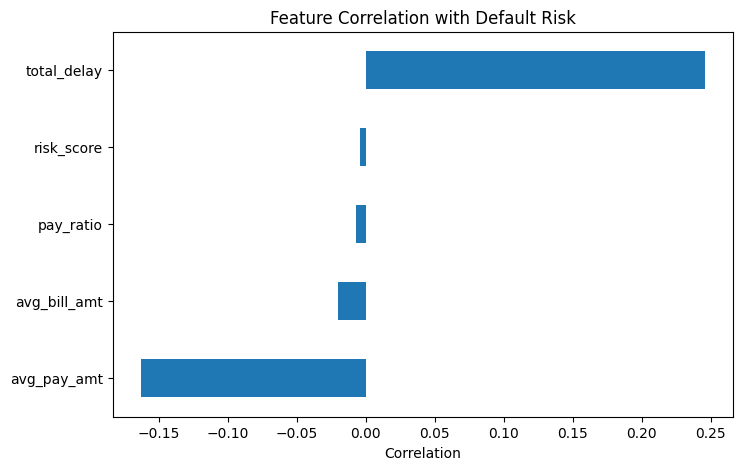

In [37]:
# ==========================================
# Correlation with Default Risk
# ==========================================

plt.figure(figsize=(8,5))

df[
    [
        'avg_bill_amt',
        'avg_pay_amt',
        'pay_ratio',
        'total_delay',
        'risk_score',
        'default_payment_next_month'
    ]
].corr()['default_payment_next_month'][:-1].sort_values().plot(
    kind='barh'
)

plt.title("Feature Correlation with Default Risk")

plt.xlabel("Correlation")

plt.show()

In [38]:
# Regression Dataset Preparation

X_reg = df[
    [
        'AGE',
        'SEX',
        'EDUCATION',
        'MARRIAGE',
        'PAY_1',
        'PAY_2',
        'PAY_3',
        'PAY_4',
        'PAY_5',
        'PAY_6',
        'avg_bill_amt',
        'avg_pay_amt'
    ]
]

y_reg = df['LIMIT_BAL']

print("Feature Shape:", X_reg.shape)
print("Target Shape:", y_reg.shape)

Feature Shape: (29965, 12)
Target Shape: (29965,)


In [39]:
# One-Hot Encoding

X_reg = pd.get_dummies(
    X_reg,
    columns=[
        'SEX',
        'EDUCATION',
        'MARRIAGE'
    ],
    drop_first=True
)

print("Updated Feature Shape:")
print(X_reg.shape)

X_reg.head()

Updated Feature Shape:
(29965, 17)


,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,avg_bill_amt,avg_pay_amt,SEX_2.0,EDUCATION_1.0,EDUCATION_2.0,EDUCATION_3.0,EDUCATION_3.5,MARRIAGE_1.0,MARRIAGE_2.0,MARRIAGE_3.0
0,24.0,1.5,1.5,-1.0,-1.0,-2.0,-2.0,1284.000000,114.833333,True,False,True,False,False,True,False,False
1,26.0,-1.0,1.5,0.0,0.0,0.0,1.5,2846.166667,833.333333,True,False,True,False,False,False,True,False
2,34.0,0.0,0.0,0.0,0.0,0.0,0.0,16942.166667,1836.333333,True,False,True,False,False,False,True,False
3,37.0,0.0,0.0,0.0,0.0,0.0,0.0,38555.666667,1398.000000,True,False,True,False,False,True,False,False
4,57.0,-1.0,0.0,-1.0,0.0,0.0,0.0,18223.166667,5598.833333,False,False,True,False,False,True,False,False


In [40]:
# Train-Test Split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:")
print(X_train_reg.shape)

print("Testing Data Shape:")
print(X_test_reg.shape)

Training Data Shape:
(23972, 17)
Testing Data Shape:
(5993, 17)


In [41]:
# Feature Scaling

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(
    X_train_reg
)

X_test_reg_scaled = scaler_reg.transform(
    X_test_reg
)

print("Scaling Completed")

Scaling Completed


In [42]:
# Linear Regression

lin_reg = LinearRegression()

lin_reg.fit(
    X_train_reg_scaled,
    y_train_reg
)

y_pred_reg = lin_reg.predict(
    X_test_reg_scaled
)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [43]:
# Model Evaluation

mae = mean_absolute_error(y_test_reg,y_pred_reg)

mse = mean_squared_error(y_test_reg,y_pred_reg)

r2 = r2_score(y_test_reg,y_pred_reg)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("R² Score            :", r2)

Mean Absolute Error : 77033.48961438723
Mean Squared Error  : 10129609529.197336
R² Score            : 0.39191468388797257


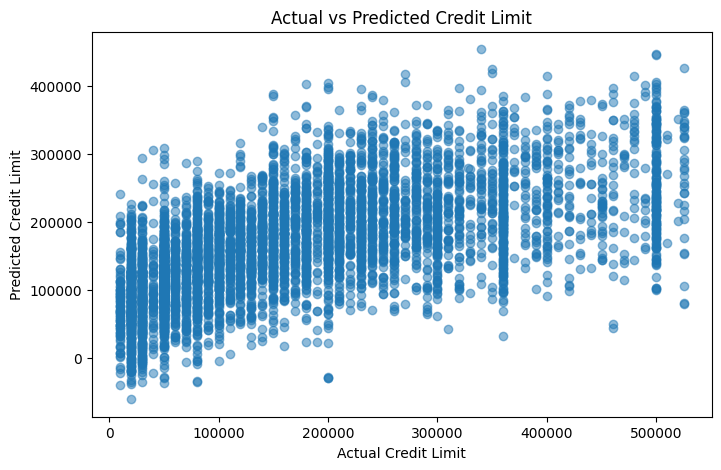

In [44]:
# Actual vs Predicted

plt.figure(figsize=(8,5))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

plt.xlabel("Actual Credit Limit")
plt.ylabel("Predicted Credit Limit")

plt.title("Actual vs Predicted Credit Limit")

plt.show()

In [45]:
# Replace NaN values

df['pay_ratio'] = df['pay_ratio'].fillna(0)

df['risk_score'] = df['risk_score'].fillna(0)

In [46]:
# Classification Dataset

X_class = df[
    [
        'LIMIT_BAL',
        'AGE',
        'SEX',
        'EDUCATION',
        'MARRIAGE',
        'PAY_1',
        'PAY_2',
        'PAY_3',
        'PAY_4',
        'PAY_5',
        'PAY_6',
        'avg_bill_amt',
        'avg_pay_amt',
        'pay_ratio',
        'total_delay',
        'risk_score'
    ]
]

y_class = df['default_payment_next_month']

print("Features Shape:", X_class.shape)
print("Target Shape:", y_class.shape)

Features Shape: (29965, 16)
Target Shape: (29965,)


In [47]:
# Check missing values in classification dataset

print(X_class.isnull().sum())

LIMIT_BAL       0
AGE             0
SEX             0
EDUCATION       0
MARRIAGE        0
PAY_1           0
PAY_2           0
PAY_3           0
PAY_4           0
PAY_5           0
PAY_6           0
avg_bill_amt    0
avg_pay_amt     0
pay_ratio       0
total_delay     0
risk_score      0
dtype: int64


In [48]:
# Encode Categorical Variables

X_class = pd.get_dummies(
    X_class,
    columns=[
        'SEX',
        'EDUCATION',
        'MARRIAGE'
    ],
    drop_first=True
)

print(X_class.shape)

(29965, 21)


In [49]:
# Train Test Split

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print(X_train_class.shape)
print(X_test_class.shape)

(23972, 21)
(5993, 21)


In [50]:
# Scaling

scaler_class = StandardScaler()

X_train_class_scaled = scaler_class.fit_transform(
    X_train_class
)

X_test_class_scaled = scaler_class.transform(
    X_test_class
)

In [51]:
# Handle Class Imbalance

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_class_scaled,
    y_train_class
)

print("Before SMOTE:")
print(y_train_class.value_counts())

print()

print("After SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
default_payment_next_month
0    18668
1     5304
Name: count, dtype: int64

After SMOTE:
default_payment_next_month
0    18668
1    18668
Name: count, dtype: int64


In [52]:
# Logistic Regression Model

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(
    X_train_smote,
    y_train_smote
)

y_pred_log = log_reg.predict(
    X_test_class_scaled
)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [53]:
# Logistic Regression Evaluation

accuracy_log = accuracy_score(
    y_test_class,
    y_pred_log
)

print("Accuracy Score:")
print(accuracy_log)

Accuracy Score:
0.6412481228099449


In [54]:
# Classification Report

print(
    classification_report(
        y_test_class,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.87      0.63      0.73      4667
           1       0.34      0.66      0.45      1326

    accuracy                           0.64      5993
   macro avg       0.61      0.65      0.59      5993
weighted avg       0.75      0.64      0.67      5993



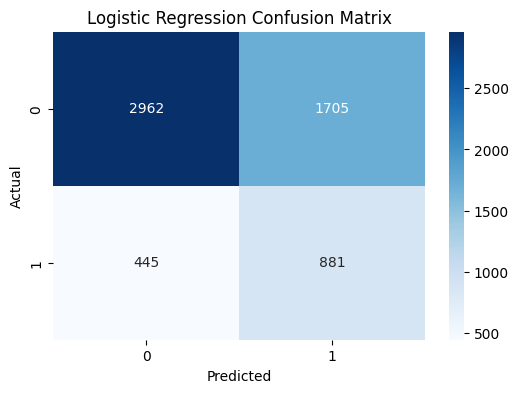

In [55]:
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test_class,
    y_pred_log
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [56]:
# Support Vector Machine (SVM)

svm_model = SVC(
    kernel='rbf',
    random_state=42
)

svm_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_svm = svm_model.predict(
    X_test_class_scaled
)

print("SVM Model Trained Successfully")

SVM Model Trained Successfully


In [57]:
# SVM Evaluation

accuracy_svm = accuracy_score(
    y_test_class,
    y_pred_svm
)

print("Accuracy Score:")
print(accuracy_svm)

Accuracy Score:
0.7710662439512765


In [58]:
# Classification Report

print(
    classification_report(
        y_test_class,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4667
           1       0.49      0.57      0.53      1326

    accuracy                           0.77      5993
   macro avg       0.68      0.70      0.69      5993
weighted avg       0.79      0.77      0.78      5993



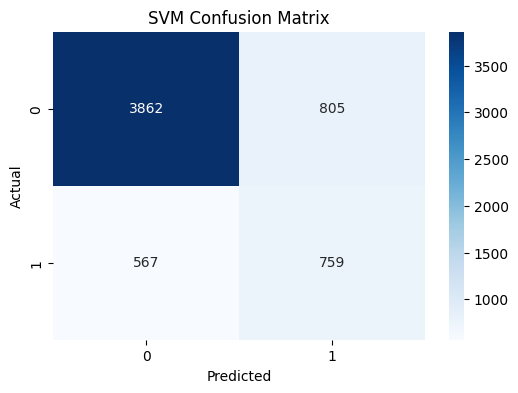

In [59]:
# Confusion Matrix

cm_svm = confusion_matrix(
    y_test_class,
    y_pred_svm
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
# Hyperparameter Tuning - SVM

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(
    X_train_smote,
    y_train_smote
)

print("Best Parameters:")
print(grid_svm.best_params_)

print()

print("Best Score:")
print(grid_svm.best_score_)

Best Parameters:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Best Score:
0.7341173066791434


In [61]:
# Best SVM Model

best_svm = grid_svm.best_estimator_

y_pred_best_svm = best_svm.predict(
    X_test_class_scaled
)

accuracy_best_svm = accuracy_score(
    y_test_class,
    y_pred_best_svm
)

print("Optimized SVM Accuracy:")
print(accuracy_best_svm)

Optimized SVM Accuracy:
0.7507091606874687


In [62]:
# Model Comparison

comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Logistic Regression',
        'SVM'
    ],
    'Score': [
        r2,
        accuracy_log,
        accuracy_svm
    ]
})

comparison

,Model,Score
0,Linear Regression,0.391915
1,Logistic Regression,0.641248
2,SVM,0.771066


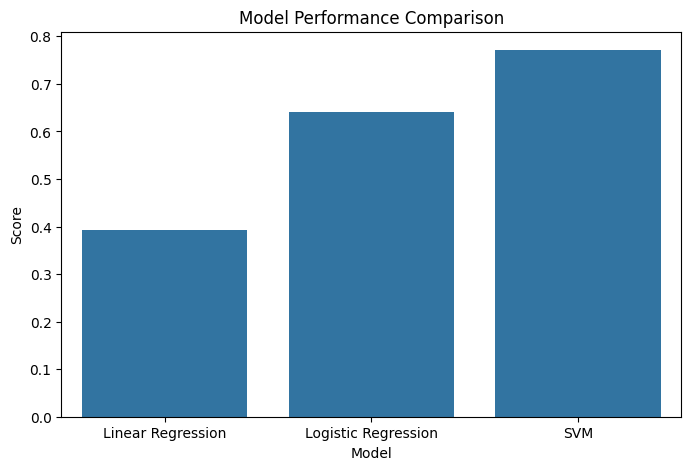

In [63]:
# Model Comparison Chart

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Score',
    data=comparison
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.show()

Credit Limit Prediction

In [65]:
# Sample Credit Limit Prediction

sample_data = X_test_reg_scaled[0:1]

predicted_limit = lin_reg.predict(sample_data)

print("Predicted Credit Limit:")
print(predicted_limit[0])

Predicted Credit Limit:
138736.89312415215


Default Risk Prediction

In [66]:
# Sample Default Prediction

sample_data = X_test_class_scaled[0:1]

prediction = svm_model.predict(sample_data)

if prediction[0] == 1:
    print("Customer is likely to default")
else:
    print("Customer is unlikely to default")

Customer is unlikely to default


In [64]:
# Save Models

joblib.dump(
    lin_reg,
    "linear_regression_model.pkl"
)

joblib.dump(
    log_reg,
    "logistic_regression_model.pkl"
)

joblib.dump(
    svm_model,
    "svm_model.pkl"
)

print("Models Saved Successfully")

Models Saved Successfully


In [67]:
# Save Scalers

joblib.dump(
    scaler_reg,
    "regression_scaler.pkl"
)

joblib.dump(
    scaler_class,
    "classification_scaler.pkl"
)

print("Scalers Saved Successfully")

Scalers Saved Successfully


# Conclusion

This project analyzed credit card customer data using machine learning techniques.

The dataset was cleaned and preprocessed before performing exploratory data analysis and feature engineering.

Three machine learning models were developed:

1. Linear Regression
2. Logistic Regression
3. Support Vector Machine (SVM)

Results:

- Linear Regression achieved an R² Score of approximately 0.39 for predicting customer credit limits.
- Logistic Regression achieved an accuracy of approximately 64% for default prediction.
- SVM achieved an accuracy of approximately 77%, making it the best-performing classification model.

The project demonstrates how machine learning can be used to predict customer behavior, identify risky customers, and support better financial decision-making.

Future improvements may include advanced ensemble models such as Random Forest, XGBoost, and Gradient Boosting to further improve prediction performance.